In [1]:
# Install necessary libraries
!pip install nibabel tensorflow matplotlib scikit-image

# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.callbacks import Callback
from IPython.display import clear_output
from google.colab import drive
import random


Mounted at /content/drive
Volume shape: (320, 280, 23)
Slice size (height, width): (320, 280)


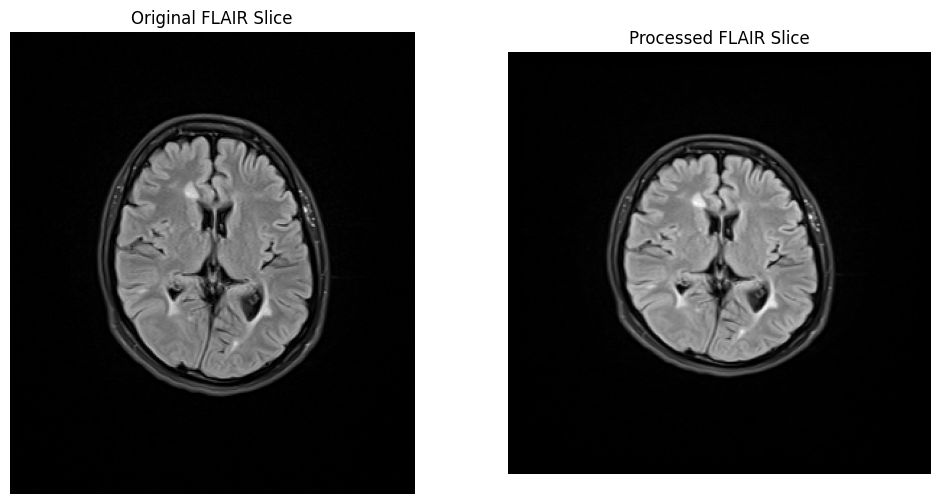

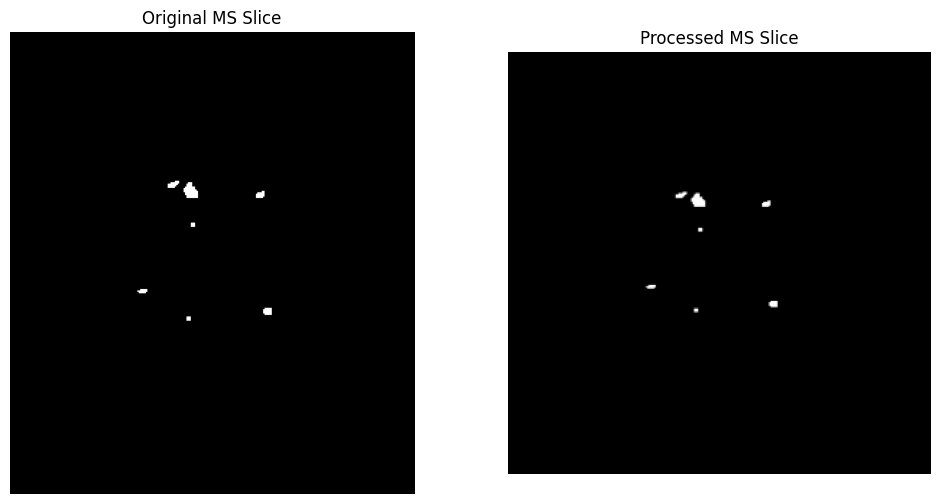

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Data loading and preprocessing functions
def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def pad_image_to_size(image, target_height=320, target_width=320, mode='constant'):
    """Pad the image to the target height and width."""
    current_height, current_width = image.shape[:2]
    delta_h = max(target_height - current_height, 0)
    delta_w = max(target_width - current_width, 0)
    top_pad = delta_h // 2
    bottom_pad = delta_h - top_pad
    left_pad = delta_w // 2
    right_pad = delta_w - left_pad
    padding = ((top_pad, bottom_pad), (left_pad, right_pad))
    padded_image = np.pad(image, padding, mode=mode)
    return padded_image

def preprocess_data(flair_slice, ms_slice, resize_target=(300, 300), pad_target=(320, 320)):
    """Normalize, resize, and pad a single slice of MRI data."""
    # Normalize the FLAIR slice
    flair_normalized = flair_slice / np.max(flair_slice) if np.max(flair_slice) > 0 else flair_slice

    # Binarize the MS slice
    ms_normalized = (ms_slice > 0.5).astype(np.float32)

    # Resize both slices to near target size
    flair_resized = resize(flair_normalized, resize_target, anti_aliasing=True)
    ms_resized = resize(ms_normalized, resize_target, anti_aliasing=True)

    # Pad both slices to ensure exact target dimensions
    flair_padded = pad_image_to_size(flair_resized, *pad_target)
    ms_padded = pad_image_to_size(ms_resized, *pad_target)

    return flair_padded, ms_padded


# Example of loading and preprocessing data
base_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Data loading and preprocessing code...
patient_number = 2
flair_image_path = f'{base_path}/Patient-{patient_number}/{patient_number}-Flair.nii'
flair_Seg_image_path = f'{base_path}/Patient-{patient_number}/{patient_number}-LesionSeg-Flair.nii'

# Load the FLAIR and MS data
flair_image = nib.load(flair_image_path)
flair_data = flair_image.get_fdata()
MS_image = nib.load(flair_Seg_image_path)
MS_data = MS_image.get_fdata()
volume_shape = flair_data.shape
print("Volume shape:", volume_shape)

# Size of an individual slice
slice_height = volume_shape[0]
slice_width = volume_shape[1]
print("Slice size (height, width):", (slice_height, slice_width))
# Specify the slice index you want to preprocess and visualize
slice_index = flair_data.shape[2] // 2  # or any specific index that is relevant

# Extract the specific slices
flair_slice = flair_data[:, :, slice_index]
MS_slice = MS_data[:, :, slice_index]

# Preprocess the extracted slices

flair_resized, MS_resized = preprocess_data(flair_slice, MS_slice)

# Visualize the original and processed slices
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(flair_slice, cmap='gray')
plt.title('Original FLAIR Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(flair_resized, cmap='gray')
plt.title('Processed FLAIR Slice')
plt.axis('off')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(MS_slice, cmap='gray')
plt.title('Original MS Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(MS_resized, cmap='gray')
plt.title('Processed MS Slice')
plt.axis('off')

plt.show()


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, LeakyReLU, MaxPooling2D, UpSampling2D, Flatten, Dense, GlobalAveragePooling2D, Concatenate, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.layers import Concatenate, Cropping2D

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, LeakyReLU
from tensorflow.keras.models import Model
import tensorflow as tf


def resize_and_concatenate(up_sampled, down_sampled):
    # Assuming up_sampled is smaller than down_sampled
    down_sampled_cropped = Cropping2D(cropping=((0, down_sampled.shape[1] - up_sampled.shape[1]),
                                                 (0, down_sampled.shape[2] - up_sampled.shape[2])))(down_sampled)
    return Concatenate()([up_sampled, down_sampled_cropped])


def print_tensor_shape(tensor, name):
    print(f"{name} shape: {tensor.shape}")
    return tensor


def extended_unet_model(input_size=(320, 320, 1)):
    inputs = Input(input_size)

    # Encoder (downsampling)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(inputs)
    c1 = LeakyReLU(alpha=0.01)(c1)
    c1 = Conv2D(8, (3, 3), kernel_initializer='he_normal', padding='same')(c1)
    c1 = LeakyReLU(alpha=0.01)(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(p1)
    c2 = LeakyReLU(alpha=0.01)(c2)
    c2 = Conv2D(16, (3, 3), kernel_initializer='he_normal', padding='same')(c2)
    c2 = LeakyReLU(alpha=0.01)(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(p2)
    c3 = LeakyReLU(alpha=0.01)(c3)
    c3 = Conv2D(32, (3, 3), kernel_initializer='he_normal', padding='same')(c3)
    c3 = LeakyReLU(alpha=0.01)(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(p3)
    c4 = LeakyReLU(alpha=0.01)(c4)
    c4 = Conv2D(64, (3, 3), kernel_initializer='he_normal', padding='same')(c4)
    c4 = LeakyReLU(alpha=0.01)(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(p4)
    c5 = LeakyReLU(alpha=0.01)(c5)
    c5 = Conv2D(128, (3, 3), kernel_initializer='he_normal', padding='same')(c5)
    c5 = LeakyReLU(alpha=0.01)(c5)
    # Bottleneck

 # Fully connected layer specifically for classification
    flattened = Flatten()(c5)
    fc = Dense(128, activation='relu')(flattened)
    classification = Dense(1, activation='sigmoid', name='classification')(fc)

    # Decoder (upsampling)
    u6 = UpSampling2D((2, 2))(c5)
    u6 = resize_and_concatenate(u6, c4)

    u7 = UpSampling2D((2, 2))(u6)
    u7 = resize_and_concatenate(u7, c3)

    u8 = UpSampling2D((2, 2))(u7)
    u8 = resize_and_concatenate(u8, c2)

    u9 = UpSampling2D((2, 2))(u8)
    u9 = resize_and_concatenate(u9, c1)
    # Segmentation output
    segmentation = Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(u9)
# Debugging: Print output shapes
    segmentation = print_tensor_shape(segmentation, "Segmentation Output")
    classification = print_tensor_shape(classification, "Classification Output")


    # Create the model with dual outputs
    model = Model(inputs=[inputs], outputs=[segmentation, classification])

    return model


from keras import backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_loss(y_true, y_pred):
    return K.binary_crossentropy(y_true, y_pred)
# Create the model
model = extended_unet_model()
model.summary()  # This will print the summary of the model including the shapes of all layers


Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 1)
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 320, 320, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 320, 320, 8)          80        ['input_1[0][0]']             
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 320, 320, 8)          0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 320, 320, 8)          584       ['leaky_re_lu[0][0]']         
        

In [ ]:
# Generate dummy data to test the model
num_samples = 10
input_shape = (320, 320, 1)
output_shape_segmentation = (320, 320, 1)
output_shape_classification = (1,)

x_dummy = np.random.random((num_samples,) + input_shape).astype(np.float32)
y_dummy_segmentation = np.random.randint(2, size=(num_samples,) + output_shape_segmentation).astype(np.float32)
y_dummy_classification = np.random.randint(2, size=(num_samples,) + output_shape_classification).astype(np.float32)

# Compile the model
model = extended_unet_model(input_size=input_shape)
model.compile(optimizer='adam',
              loss={'segmentation': dice_loss, 'classification': bce_loss},
              loss_weights={'segmentation': 1., 'classification': 0.5},
              metrics=['accuracy'])

# Train the model
model.fit(x_dummy,
          {'segmentation': y_dummy_segmentation, 'classification': y_dummy_classification},
          epochs=5)



Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 1)
Epoch 1/5
1/1 [==============================] - 4s 4s/step - loss: 0.8359 - segmentation_loss: 0.4409 - classification_loss: 0.7899 - segmentation_accuracy: 0.5005 - classification_accuracy: 0.3000
Epoch 2/5
1/1 [==============================] - 0s 49ms/step - loss: 6.1300 - segmentation_loss: 0.3808 - classification_loss: 11.4985 - segmentation_accuracy: 0.5005 - classification_accuracy: 0.7000
Epoch 3/5
1/1 [==============================] - 0s 50ms/step - loss: 0.8893 - segmentation_loss: 0.4148 - classification_loss: 0.9490 - segmentation_accuracy: 0.5005 - classification_accuracy: 0.7000
Epoch 4/5
1/1 [==============================] - 0s 48ms/step - loss: 1.1801 - segmentation_loss: 0.4377 - classification_loss: 1.4848 - segmentation_accuracy: 0.5005 - classification_accuracy: 0.3000
Epoch 5/5
1/1 [==============================] - 0s 48ms/step - loss: 3.5264 - segmentation_loss: 0.4497 - clas

In [ ]:
#SKIP IF YOU HAVE DATA

def compile_data(base_path, num_patients):
    """Compile the image data for segmentation and create binary labels for MS presence."""
    combined_images = []
    ms_masks = []
    ms_labels = []

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii')
        seg_flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')
        seg_t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-T2.nii')

        flair_img = load_nii(flair_path)
        t2_img = load_nii(t2_path)
        ms_flair_img = load_nii(seg_flair_path)
        ms_t2_img = load_nii(seg_t2_path)

        # Iterate over each slice
        for slice_idx in range(flair_img.shape[2]):
            flair_slice = flair_img[:, :, slice_idx]
            ms_slice = ms_flair_img[:, :, slice_idx]

            # Preprocess the flair slice and corresponding mask
            flair_processed, ms_processed = preprocess_data(flair_slice, ms_slice)

            combined_images.append(flair_processed)
            ms_masks.append(ms_processed)

            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

        for slice_idx in range(t2_img.shape[2]):
            t2_slice = t2_img[:, :, slice_idx]
            ms_slice = ms_t2_img[:, :, slice_idx]
            t2_processed, ms_processed = preprocess_data(t2_slice,ms_slice)
            combined_images.append(t2_processed)
            ms_masks.append(ms_processed)
            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

    # Convert lists to numpy arrays
    X = np.array(combined_images)
    Y_seg = np.array(ms_masks)
    Y_class = np.array(ms_labels)

    # Ensure proper channel dimension for CNNs
    X = np.expand_dims(X, axis=-1)
    Y_seg = np.expand_dims(Y_seg, axis=-1)

    return X, Y_seg, Y_class

num_patients = 60  # Total number of patients
X, Y_seg, Y_class = compile_data(base_path, num_patients)

base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data_U-Net'

# Ensure the directory exists
os.makedirs(base_save_path, exist_ok=True)

# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y_seg.npy'), Y_seg)
np.save(os.path.join(base_save_path, 'Y_class.npy'), Y_class)


In [ ]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data_U-Net'
X = np.load(os.path.join(base_save_path, 'X.npy'))
Y_seg = np.load(os.path.join(base_save_path, 'Y_seg.npy')).astype(np.float32)
Y_class = np.load(os.path.join(base_save_path, 'Y_class.npy')).astype(np.float32)

In [ ]:
print("shape of X:", X.shape)
print("shape of Y_seg:", Y_seg.shape)
print("shape of Y_class:", Y_class.shape)

shape of X: (2831, 320, 320, 1)
shape of Y_seg: (2831, 320, 320, 1)
shape of Y_class: (2831,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training+validation (80%) and testing (20%)
X_train_val, X_test, Y_seg_train_val, Y_seg_test, Y_class_train_val, Y_class_test = train_test_split(
    X, Y_seg, Y_class, test_size=0.20, random_state=42)

# Further split the training and validation set (from the 80% "train_val" split, allocate 20% to validation)
X_train, X_val, Y_seg_train, Y_seg_val, Y_class_train, Y_class_val = train_test_split(
    X_train_val, Y_seg_train_val, Y_class_train_val, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)    # This should show the shape of training input images
print("Shape of X_val:", X_val.shape)        # This should show the shape of validation input images
print("Shape of Y_seg_train:", Y_seg_train.shape)  # This should show the shape of training segmentation masks
print("Shape of Y_seg_val:", Y_seg_val.shape)      # This should show the shape of validation segmentation masks
print("Shape of Y_class_train:", Y_class_train.shape)  # This should show the shape of training classification labels
print("Shape of Y_class_val:", Y_class_val.shape)      # This should show the shape of validation classification labels


Shape of X_train: (1698, 320, 320, 1)
Shape of X_val: (566, 320, 320, 1)
Shape of Y_seg_train: (1698, 320, 320, 1)
Shape of Y_seg_val: (566, 320, 320, 1)
Shape of Y_class_train: (1698,)
Shape of Y_class_val: (566,)


In [ ]:
import random
import numpy as np
from scipy.ndimage import gaussian_filter, map_coordinates
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
def apply_elastic_deformation(image, alpha=0.3, sigma=0.05, is_mask=False):
    random_state = np.random.RandomState(None)
    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dz = np.zeros_like(dx)
    x, y, z = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]), np.arange(shape[2]))
    indices = np.reshape(y+dy, (-1, 1)), np.reshape(x+dx, (-1, 1)), np.reshape(z+dz, (-1, 1))
    deformed_image = map_coordinates(image, indices, order=1).reshape(shape)
    if is_mask:
        # Threshold the mask back to binary values
        deformed_image = (deformed_image > 0.5).astype(np.float32)
    return deformed_image
def random_adjust_brightness_contrast(image, brightness_range=(1, 1.0), contrast_range=(1, 1.0)):
    brightness_factor = np.random.uniform(*brightness_range)
    contrast_factor = np.random.uniform(*contrast_range)

    adjusted_image = cv2.convertScaleAbs(image, alpha=contrast_factor, beta=0)
    adjusted_image = cv2.convertScaleAbs(adjusted_image, alpha=brightness_factor, beta=0)

    # Add the channel dimension back if it's lost
    if len(adjusted_image.shape) == 2:
        adjusted_image = np.expand_dims(adjusted_image, axis=-1)

    return adjusted_image

def custom_augmentation(image, mask):
    augmentations = [
        ('elastic_deformation', apply_elastic_deformation),
        ('brightness_contrast', random_adjust_brightness_contrast)
    ]
    decision = random.random()
    if decision < 0.25:
        # No augmentation will be applied
        pass
    elif decision < 0.75:
        # Only one augmentation will be applied
        augmentation_to_apply = random.choice(augmentations[:1])  # Choose only geometric transformations
        aug_name, augmentation = augmentation_to_apply
        if aug_name == 'elastic_deformation':
            image = augmentation(image, is_mask=False)
            mask = augmentation(mask, is_mask=True)
    else:
        # A combination of augmentations will be applied
        random.shuffle(augmentations)
        for aug_name, augmentation in augmentations:
            if random.random() > 0.5:
                if aug_name == 'elastic_deformation':
                    image = augmentation(image, is_mask=False)
                    mask = augmentation(mask, is_mask=True)
                elif aug_name in ['brightness_contrast']:
                    image = augmentation(image)  # Apply only to image for intensity transformations

    return image, mask
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=custom_augmentation  # Unified custom augmentation function
)

val_datagen = ImageDataGenerator()
def train_generator(X_train, Y_seg_train, Y_class_train, batch_size):
    # Calculate the number of steps per epoch
    steps_per_epoch = np.ceil(len(X_train) / batch_size)
    current_index = 0

    while True:
        start_index = current_index
        end_index = start_index + batch_size

        # Handling wrap-around of indices
        if end_index >= len(X_train):
            end_index = len(X_train)
            current_index = 0  # Reset for the next epoch
        else:
            current_index += batch_size

        # Slice the batch
        batch_X = X_train[start_index:end_index]
        batch_Y_seg = Y_seg_train[start_index:end_index]
        batch_Y_class = Y_class_train[start_index:end_index]

        # Apply custom augmentations
        for i in range(len(batch_X)):
            batch_X[i], batch_Y_seg[i] = custom_augmentation(batch_X[i], batch_Y_seg[i])
        # Ensure the generator converts images and masks into float32
        batch_X = np.array(batch_X).astype('float32')
        batch_Y_seg = np.array(batch_Y_seg).astype('float32')

        # Convert numpy arrays to tensors
        batch_X = tf.convert_to_tensor(batch_X, dtype=tf.float32)
        batch_Y_seg = tf.convert_to_tensor(batch_Y_seg, dtype=tf.float32)
        batch_Y_class = tf.convert_to_tensor(batch_Y_class, dtype=tf.float32)


        yield batch_X, [batch_Y_seg, batch_Y_class]

def validation_generator(X_val, Y_seg_val, Y_class_val, batch_size):
    seed = 42
    image_gen = val_datagen.flow(X_val, batch_size=batch_size, seed=seed, shuffle=False)
    mask_gen = val_datagen.flow(Y_seg_val, batch_size=batch_size, seed=seed, shuffle=False)

    while True:
        images = next(image_gen)
        masks = next(mask_gen)
        # Get the current index (assuming it's the same for both generators)
        current_index = (image_gen.batch_index - 1) * batch_size
        if current_index < 0:  # In case batch_index is 0
            current_index = 0
        class_labels = Y_class_val[current_index:current_index + len(images)]

        # Convert numpy arrays to tensors
        images = tf.convert_to_tensor(images, dtype=tf.float32)
        masks = tf.convert_to_tensor(masks, dtype=tf.float32)
        class_labels = tf.convert_to_tensor(class_labels, dtype=tf.float32)

        yield images, [masks, class_labels]






# Example usage
#train_flow = train_generator(X_train, Y_seg_train, Y_class_train, batch_size=2)
#val_flow = validation_generator(X_val, Y_seg_val, Y_class_val, batch_size=2)

Training batch shapes:
Images shape: (10, 320, 320, 1)
Segmentation masks shape: (10, 320, 320, 1)
Classification labels shape: (10,)

Validation batch shapes:
Images shape: (10, 320, 320, 1)
Segmentation masks shape: (10, 320, 320, 1)
Classification labels shape: (10,)


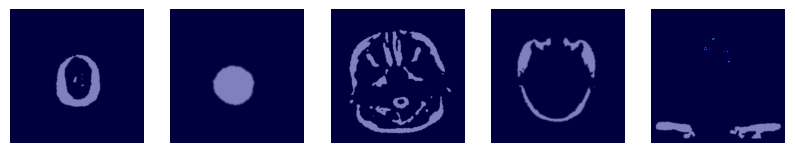

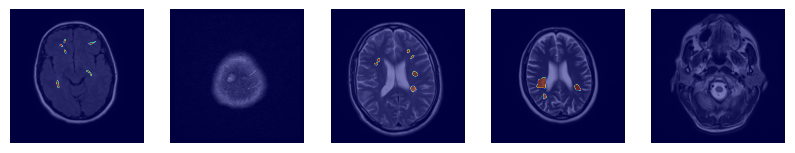

In [ ]:
#FOR TESTING PURPOSES
# Define batch size
batch_size = 10

# Create the generators
train_gen = train_generator(X_train, Y_seg_train, Y_class_train, batch_size)
val_gen = validation_generator(X_val, Y_seg_val, Y_class_val, batch_size)

# Fetch a batch from the training generator and display the shapes
train_images, [train_masks, train_class_labels] = next(train_gen)
print("Training batch shapes:")
print("Images shape:", train_images.shape)
print("Segmentation masks shape:", train_masks.shape)
print("Classification labels shape:", train_class_labels.shape)

# Fetch a batch from the validation generator and display the shapes
val_images, [val_masks, val_class_labels] = next(val_gen)
print("\nValidation batch shapes:")
print("Images shape:", val_images.shape)
print("Segmentation masks shape:", val_masks.shape)
print("Classification labels shape:", val_class_labels.shape)
import matplotlib.pyplot as plt

# Display images with masks
def display_images_with_masks(images, masks, num_display=5):
    plt.figure(figsize=(10, 10))
    for i in range(num_display):
        plt.subplot(1, num_display, i+1)
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.imshow(masks[i, :, :, 0], alpha=0.5, cmap='jet')
        plt.axis('off')
    plt.show()

# Display a few training images with masks
display_images_with_masks(train_images, train_masks)

# Display a few validation images with masks
display_images_with_masks(val_images, val_masks)



In [ ]:
# Example code to train on a single batch
single_batch_images, [single_batch_masks, single_batch_class_labels] = next(train_gen)
model.train_on_batch(single_batch_images, [single_batch_masks, single_batch_class_labels])


ResourceExhaustedError: Graph execution error:

Detected at node model_32/up_sampling2d_143/resize/ResizeNearestNeighbor defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.py", line 619, in start

  File "/usr/local/lib/python3.10/dist-packages/tornado/platform/asyncio.py", line 195, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run

  File "/usr/local/lib/python3.10/dist-packages/tornado/ioloop.py", line 685, in <lam

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


Physical devices cannot be modified after being initialized


In [ ]:
class ModelTrainer:
    def __init__(self, model, seg_optimizer, class_optimizer):
        self.model = model
        self.seg_optimizer = seg_optimizer
        self.class_optimizer = class_optimizer

    @tf.function
    def train_step(self, inputs, seg_labels, class_labels):
        with tf.GradientTape(persistent=True) as tape:
            seg_output, class_output = self.model(inputs, training=True)
            seg_loss = dice_loss(seg_labels, seg_output)
            class_loss = bce_loss(class_labels, class_output)

        seg_gradients = tape.gradient(seg_loss, [var for var in self.model.trainable_variables if 'classification' not in var.name])
        class_gradients = tape.gradient(class_loss, [var for var in self.model.trainable_variables if 'classification' in var.name])

        self.seg_optimizer.apply_gradients(zip(seg_gradients, [var for var in self.model.trainable_variables if 'classification' not in var.name]))
        self.class_optimizer.apply_gradients(zip(class_gradients, [var for var in self.model.trainable_variables if 'classification' in var.name]))

        return seg_loss, class_loss

    def train_epoch(self, train_dataset, steps_per_epoch):
        for step, (inputs, outputs) in enumerate(train_dataset):
            seg_labels, class_labels = outputs
            class_labels = tf.expand_dims(class_labels, axis=-1)
            seg_loss, class_loss = self.train_step(inputs, seg_labels, class_labels)

            if (step + 1) % 10 == 0:
                tf.print(f"Step {step + 1}/{steps_per_epoch}, Dice Loss: {seg_loss}, Class Loss: {class_loss}")

# Usage
trainer = ModelTrainer(model, Adam(), Adam())
trainer.train_epoch(train_gen, steps_per_epoch)


In [ ]:
#FOR TESTING

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Mean, BinaryAccuracy

def train_model(model, train_dataset, val_dataset, epochs, steps_per_epoch, validation_steps):
    seg_optimizer = Adam()
    class_optimizer = Adam()

    # Metrics
    train_dice_loss_metric = Mean(name='train_dice_loss')
    train_class_loss_metric = Mean(name='train_classification_loss')
    dice_metric = Mean(name='train_dice_coefficient')  # Use Mean to track average Dice coefficient over an epoch
    train_accuracy = BinaryAccuracy(name='train_accuracy')

    val_dice_loss_metric = Mean(name='val_dice_loss')
    val_class_loss_metric = Mean(name='val_classification_loss')
    val_dice_metric = Mean(name='val_dice_coefficient')
    val_accuracy = BinaryAccuracy(name='val_accuracy')

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Training loop
        for step, (inputs, outputs) in enumerate(train_dataset):
            if step >= steps_per_epoch:
                break  # Break the loop if step count exceeds what was defined by steps_per_epoch

            seg_labels, class_labels = outputs
            class_labels = tf.expand_dims(class_labels, axis=-1)

            with tf.GradientTape() as tape:
                seg_output, class_output = model(inputs, training=True)
                seg_loss = dice_loss(seg_labels, seg_output)
                class_loss = bce_loss(class_labels, class_output)

            gradients = tape.gradient([seg_loss, class_loss], model.trainable_variables)
            seg_gradients = [g for g, v in zip(gradients, model.trainable_variables) if 'classification' not in v.name]
            class_gradients = [g for g, v in zip(gradients, model.trainable_variables) if 'classification' in v.name]

            seg_optimizer.apply_gradients(zip(seg_gradients, [v for v in model.trainable_variables if 'classification' not in v.name]))
            class_optimizer.apply_gradients(zip(class_gradients, [v for v in model.trainable_variables if 'classification' in v.name]))

            # Update training metrics
            train_dice_loss_metric.update_state(seg_loss)
            train_class_loss_metric.update_state(class_loss)
            dice_metric.update_state(dice_coefficient(seg_labels, seg_output))
            train_accuracy.update_state(class_labels, class_output)

            # Print training status
            print(f"\rBatch {step+1}/{steps_per_epoch} - "
                  f"seg_loss: {train_dice_loss_metric.result().numpy():.4f}, "
                  f"class_loss: {train_class_loss_metric.result().numpy():.4f}, "
                  f"dice: {dice_metric.result().numpy():.4f}, "
                  f"accuracy: {train_accuracy.result().numpy():.4f}", end="")

        print("\n")  # New line after each epoch's training phase

        # Validation loop
        for val_step, (inputs, outputs) in enumerate(val_dataset):
            if val_step >= validation_steps:
                break  # Similarly, break the loop after the specified number of validation steps

            seg_labels, class_labels = outputs
            class_labels = tf.expand_dims(class_labels, axis=-1)
            seg_output, class_output = model(inputs, training=False)

            val_dice_loss_metric.update_state(dice_loss(seg_labels, seg_output))
            val_class_loss_metric.update_state(bce_loss(class_labels, class_output))
            val_dice_metric.update_state(dice_coefficient(seg_labels, seg_output))
            val_accuracy.update_state(class_labels, tf.cast(tf.greater(class_output, 0.5), tf.float32))

        # Print validation results
        print(f"Validation - seg_loss: {val_dice_loss_metric.result().numpy():.4f}, "
              f"class_loss: {val_class_loss_metric.result().numpy():.4f}, "
              f"dice: {val_dice_metric.result().numpy():.4f}, "
              f"accuracy: {val_accuracy.result().numpy():.4f}")

# Example usage
batch_size = 25  # Define the batch size for training and validation
steps_per_epoch = len(X_train) // batch_size  # Calculate steps per epoch for training
validation_steps = len(X_val) // batch_size   # Calculate steps for validation

# Create the generator instances
train_gen = train_generator(X_train, Y_seg_train, Y_class_train, batch_size)
val_gen = validation_generator(X_val, Y_seg_val, Y_class_val, batch_size)

# Train the model
train_model(model, train_gen, val_gen, epochs=5, steps_per_epoch=steps_per_epoch, validation_steps=validation_steps)



Epoch 1/5
Batch 67/67 - seg_loss: 0.9606, class_loss: 0.6987, dice: 0.0394, accuracy: 0.5099

Validation - seg_loss: 0.9411, class_loss: 0.6913, dice: 0.0589, accuracy: 0.4909

Epoch 2/5
Batch 67/67 - seg_loss: 0.9543, class_loss: 0.6959, dice: 0.0457, accuracy: 0.5099

Validation - seg_loss: 0.9344, class_loss: 0.6925, dice: 0.0656, accuracy: 0.4909

Epoch 3/5
Batch 67/67 - seg_loss: 0.9501, class_loss: 0.6949, dice: 0.0499, accuracy: 0.5099

Validation - seg_loss: 0.9316, class_loss: 0.6929, dice: 0.0684, accuracy: 0.4909

Epoch 4/5
Batch 67/67 - seg_loss: 0.9478, class_loss: 0.6944, dice: 0.0522, accuracy: 0.5097

Validation - seg_loss: 0.9295, class_loss: 0.6931, dice: 0.0705, accuracy: 0.4909

Epoch 5/5
Batch 67/67 - seg_loss: 0.9462, class_loss: 0.6941, dice: 0.0538, accuracy: 0.5097

Validation - seg_loss: 0.9277, class_loss: 0.6932, dice: 0.0723, accuracy: 0.4909


In [ ]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    # Plot training & validation loss values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # Plot training & validation Dice coefficient values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['segmentation_dice_coefficient'], label='Training Segmentation Dice')
    plt.plot(history.history['val_segmentation_dice_coefficient'], label='Validation Segmentation Dice')
    plt.plot(history.history['classification_accuracy'], label='Training Classification Accuracy')
    plt.plot(history.history['val_classification_accuracy'], label='Validation Classification Accuracy')
    plt.title('Dice Coefficient Over Epochs')
    plt.ylabel('Dice Coefficient')
    plt.xlabel('Epoch')
    plt.legend()

    plt.show()

plot_training_history(history)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# Define the early stopping callback
early_stopper = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    min_delta=0.01,      # Minimum change to qualify as an improvement
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    verbose=1,            # Output messages
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy


# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 5
batch_size = 25
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

loss_weights_options = [
    {'segmentation': 1.0, 'classification': 0.5},
    {'segmentation': 0.7, 'classification': 0.3},
    {'segmentation': 0.5, 'classification': 0.5}
]
learning_rate_options = [0.001, 0.0001]

best_val_accuracy = -np.inf
best_config = None

results = []

for loss_weights in loss_weights_options:
    for lr in learning_rate_options:
        print(f"Training with loss_weights={loss_weights} and learning_rate={lr}")

        # Initialize and compile the model with current hyperparameters
        model = extended_unet_model()
        optimizer = Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss={'segmentation': dice_loss, 'classification': bce_loss},
            loss_weights=loss_weights,
            metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
        )

        # Setup callbacks
        early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

        # Fit the model
        history = model.fit(
            train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
            steps_per_epoch=len(X_train) // batch_size,
            validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
            validation_steps=len(X_val) // batch_size,
            epochs=epochs,
            callbacks=[early_stopping],
            verbose=1  # Set verbose to 0 for less output during training
        )

        # Extract the best validation accuracy achieved during the training
        val_accuracy = np.max(history.history['val_classification_accuracy'])

        results.append({
            'loss_weights': loss_weights,
            'learning_rate': lr,
            'validation_accuracy': val_accuracy
        })

        # Update the best configuration if found
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_config = {
                'loss_weights': loss_weights,
                'learning_rate': lr,
                'validation_accuracy': val_accuracy
            }

print("Best configuration found:")
print(best_config)
# Optionally, save the results to a file for further analysis
# import pandas as pd
# results_df = pd.DataFrame(results)
# results_df.to_csv('grid_search_results.csv', index=False)



Training with loss_weights={'segmentation': 1.0, 'classification': 0.5} and learning_rate=0.001
Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 1)
Epoch 1/5
67/67 [==============================] - 48s 676ms/step - loss: 1.3527 - segmentation_loss: 0.9956 - classification_loss: 0.7142 - segmentation_dice_coefficient: 0.0044 - classification_accuracy: 0.5236 - val_loss: 1.3349 - val_segmentation_loss: 0.9940 - val_classification_loss: 0.6817 - val_segmentation_dice_coefficient: 0.0060 - val_classification_accuracy: 0.5636
Epoch 2/5
67/67 [==============================] - 46s 700ms/step - loss: 1.3289 - segmentation_loss: 0.9935 - classification_loss: 0.6707 - segmentation_dice_coefficient: 0.0065 - classification_accuracy: 0.6013 - val_loss: 1.3334 - val_segmentation_loss: 0.9924 - val_classification_loss: 0.6821 - val_segmentation_dice_coefficient: 0.0077 - val_classification_accuracy: 0.5712
Epoch 3/5
67/67 [==============================] - 45s 681

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 5
batch_sizes = [10, 25, 32, 50]  # Different batch sizes to test

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

best_val_accuracy = -np.inf
best_batch_size = None

results = []

for batch_size in batch_sizes:
    print(f"Training with batch_size={batch_size}")

    # Initialize and compile the model with current hyperparameters
    model = extended_unet_model()
    optimizer = Adam(learning_rate=fixed_learning_rate)
    model.compile(
        optimizer=optimizer,
        loss={'segmentation': dice_loss, 'classification': bce_loss},
        loss_weights=fixed_loss_weights,
        metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
    )

    # Setup callbacks
    early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

    # Fit the model
    history = model.fit(
        train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
        steps_per_epoch=len(X_train) // batch_size,
        validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
        validation_steps=len(X_val) // batch_size,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=1
    )

    # Extract the best validation accuracy achieved during the training
    val_accuracy = np.max(history.history['val_classification_accuracy'])

    results.append({
        'batch_size': batch_size,
        'validation_accuracy': val_accuracy
    })

    # Update the best configuration if found
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_batch_size = batch_size

print("Best batch size found:", best_batch_size)

# Optionally, save the results to a file for further analysis
# import pandas as pd
# results_df = pd.DataFrame(results)
# results_df.to_csv('batch_size_search_results.csv', index=False)


Training with batch_size=10
Segmentation Output shape: (None, 320, 320, 1)
Classification Output shape: (None, 1)
Epoch 1/5
169/169 [==============================] - 50s 274ms/step - loss: 1.3379 - segmentation_loss: 0.9952 - classification_loss: 0.6854 - segmentation_dice_coefficient: 0.0048 - classification_accuracy: 0.5527 - val_loss: 1.3151 - val_segmentation_loss: 0.9922 - val_classification_loss: 0.6457 - val_segmentation_dice_coefficient: 0.0078 - val_classification_accuracy: 0.5821
Epoch 2/5
169/169 [==============================] - 48s 276ms/step - loss: 1.2907 - segmentation_loss: 0.9884 - classification_loss: 0.6046 - segmentation_dice_coefficient: 0.0116 - classification_accuracy: 0.6925 - val_loss: 1.2830 - val_segmentation_loss: 0.9700 - val_classification_loss: 0.6262 - val_segmentation_dice_coefficient: 0.0299 - val_classification_accuracy: 0.6835
Epoch 3/5
169/169 [==============================] - 47s 277ms/step - loss: 1.2434 - segmentation_loss: 0.9663 - classific

In [ ]:
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
from IPython.display import clear_output

class PlotDualLosses(Callback):
    def __init__(self, figure_size=(12, 6)):
        super().__init__()
        self.figure_size = figure_size

    def on_train_begin(self, logs=None):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.segmentation_iou = []
        self.val_segmentation_iou = []
        self.classification_accuracy = []
        self.val_classification_accuracy = []
        self.logs = []

    def on_epoch_end(self, epoch, logs=None):
        # Store logs for potential further analysis
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss', 0))
        self.val_losses.append(logs.get('val_loss', 0))
        self.segmentation_iou.append(logs.get('segmentation_mean_iou', 0))
        self.val_segmentation_iou.append(logs.get('val_segmentation_mean_iou', 0))
        self.classification_accuracy.append(logs.get('classification_binary_accuracy', 0))
        self.val_classification_accuracy.append(logs.get('val_classification_binary_accuracy', 0))
        self.i += 1

        clear_output(wait=True)
        plt.figure(figsize=self.figure_size)
        plt.subplot(3, 1, 1)
        plt.plot(self.x, self.losses, label="Training loss")
        plt.plot(self.x, self.val_losses, label="Validation loss")
        plt.legend()
        plt.title('Training and Validation Loss')

        plt.subplot(3, 1, 2)
        plt.plot(self.x, self.segmentation_iou, label="Training Segmentation IoU")
        plt.plot(self.x, self.val_segmentation_iou, label="Validation Segmentation IoU")
        plt.legend()
        plt.title('Training and Validation IoU for Segmentation')

        plt.subplot(3, 1, 3)
        plt.plot(self.x, self.classification_accuracy, label="Training Classification Accuracy")
        plt.plot(self.x, self.val_classification_accuracy, label="Validation Classification Accuracy")
        plt.legend()
        plt.title('Training and Validation Accuracy for Classification')

        plt.tight_layout()
        plt.show()


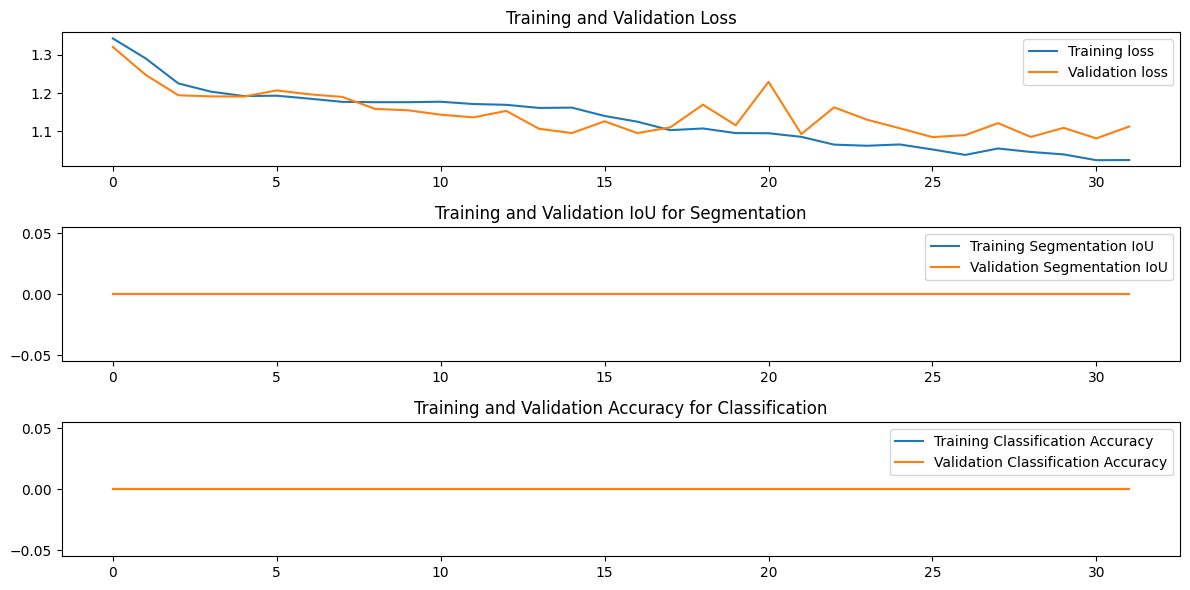


Epoch 32: val_loss did not improve from 1.08131
67/67 [==============================] - 47s 710ms/step - loss: 1.0246 - segmentation_loss: 0.8201 - classification_loss: 0.4090 - segmentation_dice_coefficient: 0.1800 - classification_accuracy: 0.8123 - val_loss: 1.1124 - val_segmentation_loss: 0.8552 - val_classification_loss: 0.5144 - val_segmentation_dice_coefficient: 0.1462 - val_classification_accuracy: 0.7616
Epoch 33/50
25/67 [==========>...................] - ETA: 27s - loss: 1.0070 - segmentation_loss: 0.8161 - classification_loss: 0.3818 - segmentation_dice_coefficient: 0.1839 - classification_accuracy: 0.8080

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, MeanIoU
from tensorflow.keras.losses import BinaryCrossentropy

# Assuming PlotDualLosses and other necessary imports are defined elsewhere
epochs = 50
batch_size = 25  # Optimal batch size determined from experiments

# Fixed learning rate and loss weights
fixed_learning_rate = 0.001  # Replace with your chosen fixed learning rate
fixed_loss_weights = {'segmentation': 1.0, 'classification': 0.5}  # Replace with your chosen fixed loss weights

# Initialize and compile the model with current hyperparameters
model = extended_unet_model()
optimizer = Adam(learning_rate=fixed_learning_rate)
model.compile(
    optimizer=optimizer,
    loss={'segmentation': dice_loss, 'classification': bce_loss},
    loss_weights=fixed_loss_weights,
    metrics={'segmentation': dice_coefficient, 'classification': 'accuracy'}
)

# Setup callbacks
early_stopping = EarlyStopping(monitor='val_classification_accuracy', patience=5, verbose=1, restore_best_weights=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Setup the plot losses callback
plot_dual_losses = PlotDualLosses()
from tensorflow.keras.callbacks import ModelCheckpoint

# Setup model checkpointing
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
# Fit the model
history = model.fit(
    train_generator(X_train, Y_seg_train, Y_class_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=validation_generator(X_val, Y_seg_val, Y_class_val, batch_size),
    validation_steps=len(X_val) // batch_size,
    epochs=epochs,
    callbacks=[plot_dual_losses, early_stopping, checkpoint],
    verbose=1
)

# Extract the best validation accuracy achieved during the training
best_val_accuracy = np.max(history.history['val_classification_accuracy'])

print(f"Best validation accuracy with batch size {batch_size}:", best_val_accuracy)


In [ ]:
#Implement in a way where classification loss is only used on layer connected to bottle neck layer (maybe fully connected layers)

In [ ]:
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 320, 320, 1)]        0         []                            
                                                                                                  
 conv2d_10 (Conv2D)          (None, 320, 320, 8)          80        ['input_2[0][0]']             
                                                                                                  
 leaky_re_lu_10 (LeakyReLU)  (None, 320, 320, 8)          0         ['conv2d_10[0][0]']           
                                                                                                  
 conv2d_11 (Conv2D)          (None, 320, 320, 8)          584       ['leaky_re_lu_10[0][0]']      
                                                                                            

In [ ]:
# Predict on a batch
predictions = model.predict(X_train[:batch_size])

# Print the type and shape of each output in the predictions list
for i, pred in enumerate(predictions):
    print(f"Shape of predictions from output {i}:", pred.shape)



1/1 [==============================] - 0s 22ms/step
Shape of predictions from output 0: (2, 320, 320, 1)
Shape of predictions from output 1: (2, 1)


In [ ]:
# Import the necessary function
from tensorflow.keras.losses import BinaryCrossentropy

# Initialize the loss function
loss_func = BinaryCrossentropy()

# Calculate loss for the segmentation output
seg_loss = loss_func(Y_seg_train[:batch_size], predictions[0])
print("Segmentation loss:", seg_loss.numpy())

# Calculate loss for the classification output
class_loss = loss_func(Y_class_train[:batch_size], predictions[1])
print("Classification loss:", class_loss.numpy())


Segmentation loss: nan
Classification loss: nan


In [ ]:
print("Unique values in segmentation labels:", np.unique(Y_seg_train[:batch_size]))
print("Unique values in classification labels:", np.unique(Y_class_train[:batch_size]))


Unique values in segmentation labels: [0.]
Unique values in classification labels: [0]


In [ ]:
print("Data type of X_train:", X_train.dtype)
print("Data type of Y_seg_train:", Y_seg_train.dtype)
print("Data type of Y_class_train:", Y_class_train.dtype)
# Assuming you have a preprocessing function applied like this:
X_processed = preprocess_data(X_train[0],Y_seg_train[0])
print("Data type after preprocessing X_train[0]:", X_processed.dtype)


Data type of X_train: float32
Data type of Y_seg_train: float32
Data type of Y_class_train: float32


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2)  and requested shape (3,2)